In [7]:
import numpy as np
import torch


seed = 1712
np.random.seed(seed)
torch.manual_seed(seed)

In [8]:
hidden_channels = 64
num_gnn_layers = 3

In [9]:
num_rounds = 500
num_epochs = 2
eval_round = num_rounds//10
batch_size = 32
num_train = 1000

num_test = 500
num_eval = 500

lr = 5e-4
step_size = num_rounds//10
gamma = 0.8

client_fraction = 0.6

num_epochs_cen = 1000
cen_lr = 5e-3

In [10]:
num_ue = 6
num_ap = 30
num_antenna = 1
tau=20; power_f=0.2; D=1; f=1900; Hb=15; Hm=1.65; d0=0.01;d1=0.05;


noise_p = 10**((-203.975+10*np.log10(20*10**6)+9)/10);
rho_d = power_f/noise_p
rho_p = power_f/noise_p

In [11]:
num_clients = num_ap
eval_round = eval_round if eval_round else num_rounds//10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Create Data

In [12]:
from Utils.data_gen import create_graph, build_loader
from torch_geometric.loader import DataLoader

In [13]:
import scipy.io
from Utils.data_gen_ldpc import build_cen_loader_ldpc, build_decen_loader_ldpc


file_name = f'dl_data_with_power_10000_{num_ue}_{num_ap}'
mat_data = scipy.io.loadmat('Data/' + file_name + '.mat')
beta_all = mat_data['betas']
gamma_all = mat_data['Gammas']
power_all = mat_data['power']/rho_d
phi_all = mat_data['Phii_cf'].transpose(0, 2, 1)
opt_train_rates = mat_data['R_cf_opt_min'][0]

label_all = power_all

perm = np.random.RandomState(seed).permutation(beta_all.shape[0])
train_idx = perm[:num_train]
test_idx  = perm[num_train: num_train + num_test]


## Decentralized Data
# Beta_all, Phi_all = beta_all[train_idx], phi_all[train_idx]
# train_data = create_graph(Beta_all, Phi_all, beta_mean, beta_std, 'het')
# train_loader = build_loader(train_data, batch_size, seed=seed, drop_last=True)

# Beta_test, Phi_test = beta_all[test_idx], phi_all[test_idx]
# test_data = create_graph(Beta_test, Phi_test, beta_mean, beta_std, 'het')
# test_loader = build_loader(test_data, batch_size, seed=seed, drop_last=True)

train_data, train_loader = build_decen_loader_ldpc(
    beta_all[train_idx],
    gamma_all[train_idx], 
    label_all[train_idx],
    phi_all[train_idx],
    batch_size, seed=seed
)
test_data, test_loader = build_decen_loader_ldpc(
    beta_all[test_idx], 
    gamma_all[test_idx],
    label_all[test_idx],
    phi_all[test_idx], 
    batch_size, seed=seed
)



## Centralized Data
train_data_cen, train_loader_cen = build_cen_loader_ldpc(
    beta_all[train_idx],
    gamma_all[train_idx], 
    label_all[train_idx],
    phi_all[train_idx],
    batch_size, isShuffle=True
)
test_data_cen, test_loader_cen = build_cen_loader_ldpc(
    beta_all[test_idx], 
    gamma_all[test_idx],
    label_all[test_idx],
    phi_all[test_idx], 
    batch_size
)

c:\Users\wine\Giang\Code\Viet\new\densityevolution\GNN_FL_cf_mMIMO\Utils\data_gen_ldpc.py:152: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  data.y = torch.tensor([eta_single_all], dtype=torch.float32).to(device)


# Init Model

In [14]:
from Models.LDPC_inspired_GNN import LDPCGNN
from torch.optim.lr_scheduler import StepLR


In [15]:
torch.set_default_dtype(torch.float32) 

num_gnn_layers = 3
num_epochs_cen = 1000
cen_lr = 2e-3 # 5e-3  the the best results
batch_size = 32
hidden_channels = 64 # min 32

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = train_data_cen[0]   
dim_dict = {
    'VN': data['VN'].x.size(-1),
    'CN': data['CN'].x.size(-1),
    'edge': data['CN', 'to', 'VN'].edge_attr.size(-1),
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]

model = LDPCGNN(
    metadata=metadata,
    dim_dict=dim_dict,
    hidden_dim=32,
    msg_dim=32,
    num_iter=3,
    hid_layers=32
).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=num_epochs_cen//10, gamma=0.8
)
criterion = torch.nn.BCEWithLogitsLoss()


In [17]:
from Utils.decentralized_train import FedAvg
fed = FedAvg(client_fraction=client_fraction)

In [18]:
def lr_factor(round_idx, warmup_rounds, gamma):
    """Round-wise LR factor in (0, 1]. round_idx is 0-based."""
    if round_idx < warmup_rounds:
        # linear warmup
        return float(round_idx + 1) / warmup_rounds
    else:
        # slow exponential decay
        return gamma ** (round_idx - warmup_rounds)

# New

In [19]:
data = train_data_cen[0]   
dim_dict = {
    'VN': data['VN'].x.size(-1),
    'CN': data['CN'].x.size(-1),
    'edge': data['CN', 'to', 'VN'].edge_attr.size(-1),
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]

In [20]:
from Models.LDPC_new import LDPCPowerGNN, train_model, eval_model

model = LDPCPowerGNN(
    dim_dict['VN'], dim_dict['CN'], dim_dict['edge'],
    message_dim=64,
    hidden=32,
    num_iter=4,
    gamma_idx=1,
    power_limit=1.0
).to(device)
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
# cen_optimizer = torch.optim.Adam(cen_model.parameters(), lr=cen_lr)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cen_lr, weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=num_epochs_cen//10, gamma=0.8
)
# cen_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     cen_optimizer, T_max=num_epochs_cen, eta_min=5e-5
# )

# cen_scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     cen_optimizer, max_lr=cen_lr,
#     steps_per_epoch=len(train_loader_cen),
#     epochs=num_epochs_cen, pct_start=0.1
# )

## Training

In [21]:
all_rate = []
all_rate_test = []
eval_epochs_cen = num_epochs_cen//10 if num_epochs_cen//10 else 1
print(f'Training Centralized GNN for benchmark...')
print(f'Optimal rate: train {np.mean(opt_train_rates[train_idx])}, test {np.mean(opt_train_rates[test_idx])}')
for epoch in range(num_epochs_cen):
    model.train()
    train_loss, c_loss = train_model(
        epoch/(2*num_epochs_cen//3),
        train_loader_cen, model, optimizer,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
    )
    
    model.eval()
    with torch.no_grad():
        train_eval, _ = eval_model(
            train_loader_cen, model,
            tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
        )   
        test_eval, test_c_loss = eval_model(
            test_loader_cen, model,
            tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
        )  
    all_rate.append(train_eval)    
    all_rate_test.append(test_eval)    
    scheduler.step()
    if epoch%eval_epochs_cen==0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Constraint Loss: {c_loss:.4f} | "
            f"Train Rate: {train_eval:.4f} | "
            f"Test Rate: {test_eval:.4f} | "
            f"Test Constraint Loss: {test_c_loss:.4f}"
        )

Training Centralized GNN for benchmark...
Optimal rate: train 1.7364940499026227, test 1.7908943108938773
Epoch 001/1000 | Train Loss: 74986274.0525 | Train Constraint Loss: 74986274.0525 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 101/1000 | Train Loss: 0.0000 | Train Constraint Loss: 0.0000 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 201/1000 | Train Loss: 0.0000 | Train Constraint Loss: 0.0000 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 301/1000 | Train Loss: 0.0000 | Train Constraint Loss: 0.0000 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 401/1000 | Train Loss: 0.0000 | Train Constraint Loss: 0.0000 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 501/1000 | Train Loss: 0.0000 | Train Constraint Loss: 0.0000 | Train Rate: 0.0000 | Test Rate: 0.0000 | Test Constraint Loss: 0.0000
Epoch 601/1000 | Train Loss: 0.0000 | Tr

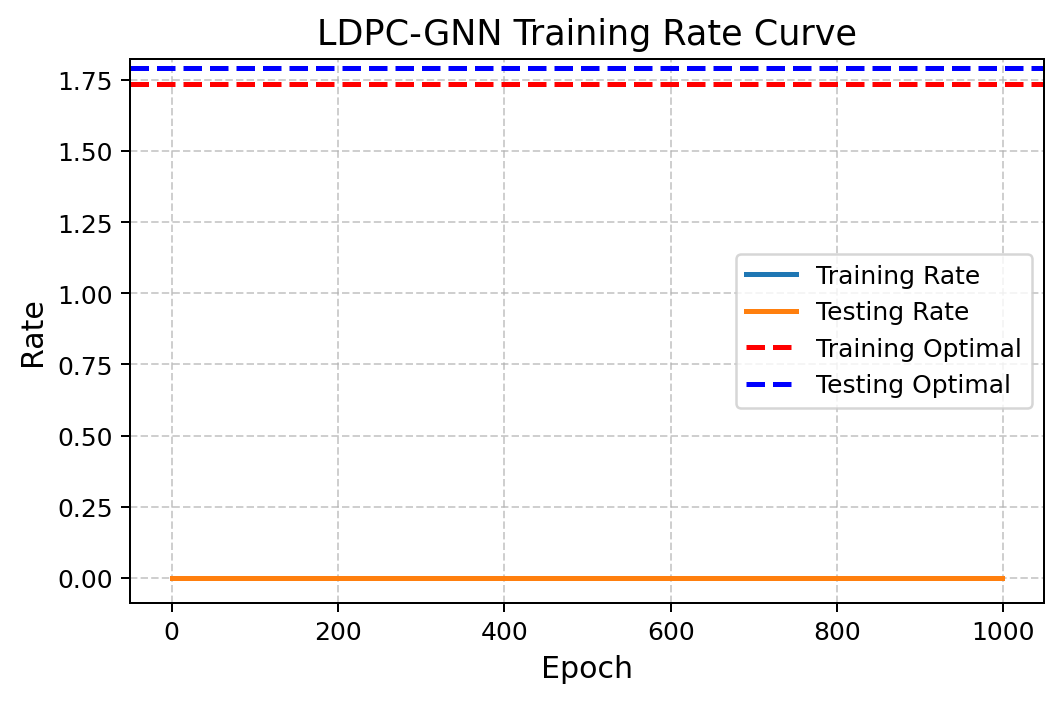

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4), dpi=180)
plt.plot(all_rate, label='Training Rate', linewidth=2)
plt.plot(all_rate_test, label='Testing Rate', linewidth=2)
plt.axhline(y=np.mean(opt_train_rates[train_idx]), linewidth=2, color='r', linestyle='--', label='Training Optimal')
plt.axhline(y=np.mean(opt_train_rates[test_idx]), linewidth=2, color='b', linestyle='--', label='Testing Optimal')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.title('LDPC-GNN Training Rate Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation

In [23]:
print('Different data eval...')
num_eval = 500
file_name = f'dl_data_with_power_10000_{num_ue}_{num_ap}'
# file_name = f'cf_data_1000_{num_ue}_{num_ap}'
# file_name = 'cf_data_1000_6_30'
# file_name = f'eval_data_{num_eval}_{num_ue}_{num_ap}'
eval_mat = scipy.io.loadmat('Data/' + file_name + '.mat')
Beta_eval = eval_mat['betas']
Gamma_eval = eval_mat['Gammas']
Power_eval = eval_mat['power']/rho_d
Phi_eval = eval_mat['Phii_cf'].transpose(0,2,1)

opt_rates = eval_mat['R_cf_opt_min'][0]

Label_eval = opt_rates

# beta_mean_eval = np.mean(Beta_eval)
# beta_std_eval = np.std(Beta_eval)
# Beta_eval = (Beta_eval - beta_mean_eval) / (beta_std_eval)

# eval_data = create_graph(Beta_eval, Phi_eval, beta_mean_eval, beta_std_eval,  'het')
# eval_loader = build_loader(eval_data, num_eval, seed=1712, drop_last=True)

# eval_data_cen = create_graph(Beta_eval, Phi_eval, beta_mean_eval, beta_std_eval, 'het', isDecentralized=False)
# eval_loader_cen = DataLoader(eval_data_cen, batch_size=num_eval, shuffle=True)  

eval_idx = perm[-num_eval:]
# eval_idx = perm[:num_eval]
# eval_data_cen, eval_loader_cen = build_cen_loader(Beta_eval[eval_idx], Phi_eval[eval_idx], num_eval, isShuffle=True)
opt_rates = opt_rates[eval_idx]

eval_data_cen, eval_loader_cen = build_cen_loader_ldpc(
    Beta_eval[eval_idx], 
    Gamma_eval[eval_idx],
    Label_eval[eval_idx],
    Phi_eval[eval_idx], 
    num_eval
)




Different data eval...


In [24]:
from Models.LDPC_new import  loss_function
model.eval()
for batch in eval_loader_cen:
    batch = batch.to(device)
    num_graph = batch.num_graphs
    x_dict, edge_dict, edge_index = model(batch)
    
    gnn_rates, all_one_rates, c_loss = loss_function(
        batch, x_dict, edge_dict,edge_index,
        tau=tau, rho_p=power_f, rho_d=power_f, num_antenna=num_antenna, 
        eval_mode=True
    )

gnn_rates = gnn_rates.detach().cpu().numpy()
all_one_rates = all_one_rates.detach().cpu().numpy()

In [25]:
print(f'Avg rate centralized: {np.mean(gnn_rates):0.4f}')
print(f'Avg rate opt: {np.mean(opt_rates):0.4f}')
print(np.mean(gnn_rates) / np.mean(opt_rates))

Avg rate centralized: 0.0000
Avg rate opt: 1.7419
0.0


In [26]:
max_value = np.ceil(max(np.max(all_one_rates), np.max(gnn_rates), np.max(opt_rates))*100)/100

In [27]:
min_rate, max_rate = 0, max_value
# y_axis = np.arange(0, 1.0, 1/202)
y_axis = np.linspace(0, 1, num_eval+2)
gnn_rates.sort();  opt_rates.sort(); all_one_rates.sort();
gnn_rates = np.insert(gnn_rates, 0, min_rate); gnn_rates = np.insert(gnn_rates,num_eval+1,max_rate)
all_one_rates = np.insert(all_one_rates, 0, min_rate); all_one_rates = np.insert(all_one_rates,num_eval+1,max_rate)
opt_rates = np.insert(opt_rates, 0, min_rate); opt_rates = np.insert(opt_rates,num_eval+1,max_rate)

# Visualization

In [28]:
import matplotlib.pyplot as plt


# Check the fucking power thresh

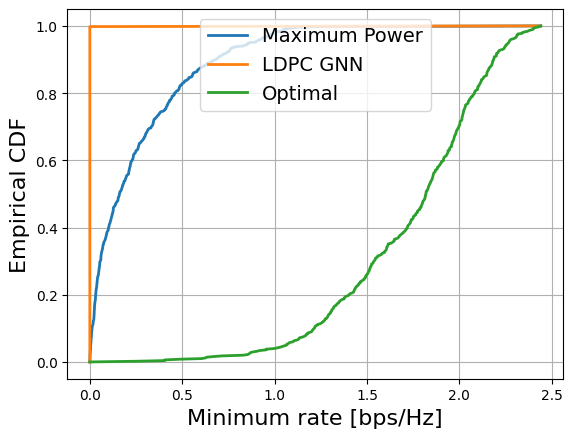

In [29]:
plt.plot(all_one_rates, y_axis, label = 'Maximum Power', linewidth=2)
plt.plot(gnn_rates, y_axis, label = 'LDPC GNN', linewidth=2)
plt.plot(opt_rates, y_axis, label = 'Optimal', linewidth=2)
plt.xlabel('Minimum rate [bps/Hz]', {'fontsize':16})
plt.ylabel('Empirical CDF', {'fontsize':16})
plt.legend(fontsize = 14)
plt.grid()
plt.show()

# Test

In [30]:
all_rate = []
eval_epochs_cen = num_epochs_cen//10 if num_epochs_cen//10 else 1
print(f'Training Centralized GNN for benchmark...')
for epoch in range(num_epochs_cen):
    model.train()
    train_loss, train_rate = train_model(
        epoch/(2*num_epochs_cen//3),
        train_loader_cen, model, optimizer,
        tau=tau, rho_p=power_f, rho_d=power_f, num_antenna=num_antenna
    )
    train_loss, c_loss = train_model(
        epoch/(2*num_epochs_cen//3),
        train_loader_cen, model, optimizer,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
    )
    model.eval()
    with torch.no_grad():
        train_eval = eval(
            train_loader_cen, model,
            tau=tau, rho_p=power_f, rho_d=power_f, num_antenna=num_antenna
        )
        test_eval = eval(
            test_loader_cen, model,
            tau=tau, rho_p=power_f, rho_d=power_f, num_antenna=num_antenna
        )
    all_rate.append(train_rate.cpu())    
    scheduler.step()
    if epoch%eval_epochs_cen==0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Loss: {train_rate:.4f} | "
            f"Train Rate: {train_eval:.4f} | "
            f"Test Rate: {test_eval:.4f} "
        )

Training Centralized GNN for benchmark...


TypeError: eval() takes no keyword arguments

In [ ]:
from Utils.comm import variance_calculate, rate_from_component, component_calculate
Beta_all = eval_mat['betas'][:10]
Phi_all = eval_mat['Phii_cf'][:10].transpose(0,2,1)

dtype = torch.float64 

num_sam, num_ap, num_ue = Beta_all.shape

largeScaleMat = torch.tensor(Beta_all, dtype=dtype)
pilotMatrix = torch.tensor(Phi_all, dtype=dtype)
chanelVarMat = variance_calculate(largeScaleMat, pilotMatrix, tau, power_f)

powerMat = torch.rand(Beta_all.shape, dtype=dtype)

all_DS, all_PC, all_UI = component_calculate(powerMat, chanelVarMat, largeScaleMat, pilotMatrix, rho=power_f)
rate_mat = rate_from_component(all_DS, all_PC, all_UI, num_antenna)

In [ ]:
PC = torch.zeros(num_sam, num_ue, num_ue, dtype=dtype)
SINR = torch.zeros(num_sam, num_ue, dtype=dtype)
UI = torch.zeros(num_sam, num_ue, dtype=dtype)

for each_sam in range(num_sam):
    for k_prime in range(num_ue):
        for k in range(num_ue):
            pc = pilotMatrix[each_sam, k_prime, :] @ pilotMatrix[each_sam, k, :] 
            tmp = torch.sqrt(powerMat[each_sam,:,k_prime]) *  chanelVarMat[each_sam,:,k_prime] * largeScaleMat[each_sam,:,k] / largeScaleMat[each_sam,:,k_prime]
            PC[each_sam, k_prime, k] =  torch.sum(tmp) * pc
        
PC = torch.square(PC)

for each_sam in range(num_sam):
    for k in range(num_ue):
        for k_prime in range(num_ue):
            tmp = powerMat[each_sam, :, k_prime] * chanelVarMat[each_sam,:, k_prime] * largeScaleMat[each_sam,:,k]
            UI[each_sam, k] += torch.sum(tmp)
for each_sam in range(num_sam):
    for k in range(num_ue):
        num = 0
        for m in range(num_ap):
            num += torch.sqrt(powerMat[each_sam,m,k]) * chanelVarMat[each_sam,m,k]
        SINR[each_sam, k] = torch.square(num)/(1 + UI[each_sam, k] + torch.sum(PC[each_sam,:,k]) - PC[each_sam,k,k])
        
rate = torch.log2(1+SINR)

In [ ]:
print(rate_mat.dtype)          # should show torch.float64
print(rate.dtype)              # from loop version, also float64
print((rate_mat - rate).abs().max())